<table class="ee-notebook-buttons" align="left"><td>
<a target="_blank"  href="http://colab.research.google.com/github/google/earthengine-community/blob/master/guides/linked/ee-api-colab-setup.ipynb">
    <img src="https://www.tensorflow.org/images/colab_logo_32px.png" /> Run in Google Colab</a>
</td><td>
<a target="_blank"  href="https://github.com/google/earthengine-community/blob/master/guides/linked/ee-api-colab-setup.ipynb"><img width=32px src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" /> View source on GitHub</a></td></table>

In [10]:
import ee

In [11]:
# Trigger the authentication flow.
ee.Authenticate()

# Initialize the library.
ee.Initialize(project='air-quality-505512')

In [12]:
!pip install geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 71.1 MB/s eta 0:00:00


In [13]:
import ee
import geemap

# 1. Definim aria de test (București + o rază de 50km)
punct_central = ee.Geometry.Point([26.10, 44.43])
regiune_interes = punct_central.buffer(50000)

# 2. Apelăm dataset-ul Sentinel-5P pentru NO2
dataset = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2') \
            .select('tropospheric_NO2_column_number_density') \
            .filterBounds(regiune_interes) \
            .filterDate('2023-01-01', '2023-01-31')

# 3. Agregarea datelor (Compozitul lunar)
media_lunara = dataset.mean().clip(regiune_interes)

# 4. Setăm culorile pentru hartă
parametri_vizualizare = {
  'min': 0,
  'max': 0.0002,
  'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

# 5. Generăm harta interactivă
harta = geemap.Map(center=[44.43, 26.10], zoom=9)
harta.addLayer(media_lunara, parametri_vizualizare, 'Media NO2 Bucuresti (Ian 2023)')
harta

Map(center=[44.43, 26.1], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

In [14]:
# 1. Definim granițele României
romania = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Romania'))

# 2. Definim NOUA funcție care elimină norii
def elimina_norii(imagine):
    # Folosim banda 'cloud_fraction' din lista returnată de eroare
    fractie_nori = imagine.select('cloud_fraction')
    # Păstrăm doar pixelii unde acoperirea de nori este mai mică de 30% (< 0.3)
    masca = fractie_nori.lt(0.3)
    return imagine.updateMask(masca)

# 3. Apelăm dataset-ul, aplicăm filtrul și decupăm pe România
dataset_filtrat = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2') \
                    .filterBounds(romania) \
                    .filterDate('2023-01-01', '2023-01-31') \
                    .map(elimina_norii) \
                    .select('tropospheric_NO2_column_number_density')

# 4. Calculăm media lunară curată
media_lunara_ro = dataset_filtrat.mean().clip(romania)

# 5. Generăm noua hartă la nivel național
parametri_vizualizare = {
  'min': 0,
  'max': 0.0002,
  'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

harta_ro = geemap.Map(center=[45.9, 25.0], zoom=6)
harta_ro.addLayer(media_lunara_ro, parametri_vizualizare, 'NO2 Romania (Ian 2023 - Fara Nori)')
harta_ro.addLayer(ee.Image().paint(romania, 0, 2), {'palette': 'black'}, 'Granite Romania')
harta_ro

Map(center=[45.9, 25.0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', …

Se descarcă datele... te rog așteaptă.
Extracție reușită! Se generează graficul...


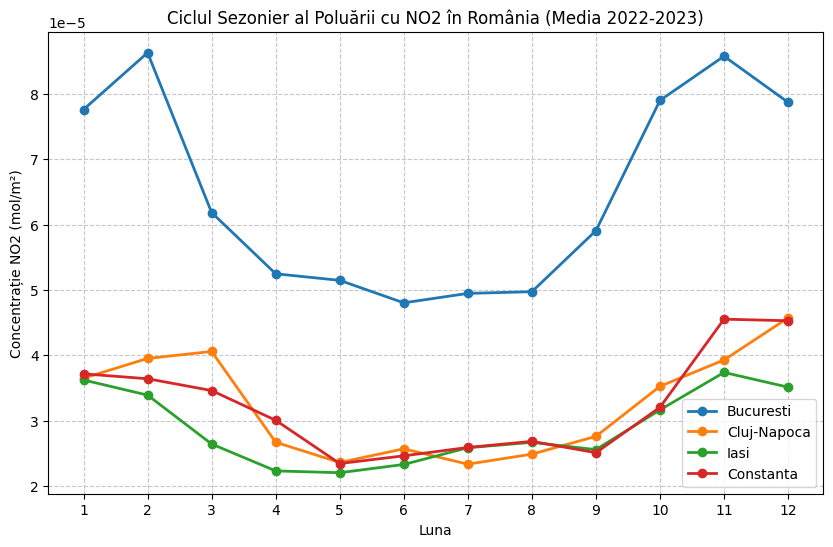

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import ee

# 1. Definim orașele și geometriile lor direct într-un dicționar standard Python
orase = {
    'Bucuresti': ee.Geometry.Point([26.10, 44.43]).buffer(10000),
    'Cluj-Napoca': ee.Geometry.Point([23.59, 46.77]).buffer(10000),
    'Iasi': ee.Geometry.Point([27.58, 47.15]).buffer(10000),
    'Constanta': ee.Geometry.Point([28.63, 44.17]).buffer(10000)
}

# 2. Funcția de mascare a norilor (<30% acoperire)
def elimina_norii(imagine):
    masca = imagine.select('cloud_fraction').lt(0.3)
    return imagine.updateMask(masca)

# 3. Setăm arhiva corectă (OFFL) și anii compleți de analiză (2022-2023)
dataset = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2') \
            .filterDate('2022-01-01', '2023-12-31') \
            .map(elimina_norii) \
            .select('tropospheric_NO2_column_number_density')

inregistrari = []

print("Se descarcă datele... te rog așteaptă.")

# 4. Extragem datele manual, pas cu pas, pentru a evita erorile de server
for nume_oras, geometrie in orase.items():
    for luna in range(1, 13):
        # Filtrăm doar luna curentă
        dataset_lunar = dataset.filter(ee.Filter.calendarRange(luna, luna, 'month'))

        # Facem media acelei luni și reducem regiunea la granițele orașului
        valoare_dict = dataset_lunar.mean().reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometrie,
            scale=1000
        ).getInfo() # .getInfo() aduce datele din Cloud direct în Python

        # Salvăm valoarea dacă există
        if valoare_dict and 'tropospheric_NO2_column_number_density' in valoare_dict:
            valoare = valoare_dict['tropospheric_NO2_column_number_density']
            if valoare is not None:
                inregistrari.append({
                    'Oras': nume_oras,
                    'Luna': luna,
                    'NO2': valoare
                })

# 5. Generăm tabelul și graficul final
df = pd.DataFrame(inregistrari)

if df.empty:
    print("Nu s-au putut extrage datele.")
else:
    print("Extracție reușită! Se generează graficul...")
    plt.figure(figsize=(10, 6))

    for oras in df['Oras'].unique():
        date_oras = df[df['Oras'] == oras].sort_values('Luna')
        plt.plot(date_oras['Luna'], date_oras['NO2'], marker='o', linewidth=2, label=oras)

    plt.title('Ciclul Sezonier al Poluării cu NO2 în România (Media 2022-2023)')
    plt.xlabel('Luna')
    plt.ylabel('Concentrație NO2 (mol/m²)')
    plt.xticks(range(1, 13))
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

In [16]:
import ee
import time

# Asigură-te că ești autentificat (rulează asta dacă ai dat restart la Colab)
# ee.Initialize(project='id-ul-proiectului-tau')

# 1. Definim granițele României
romania = ee.FeatureCollection('FAO/GAUL/2015/level0').filter(ee.Filter.eq('ADM0_NAME', 'Romania'))

# 2. Funcția de mascare a norilor
def elimina_norii(imagine):
    masca = imagine.select('cloud_fraction').lt(0.3)
    return imagine.updateMask(masca)

# 3. Luăm datele istorice
dataset = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_NO2') \
            .filterDate('2022-01-01', '2023-12-31') \
            .map(elimina_norii) \
            .select('tropospheric_NO2_column_number_density')

# Parametrii vizuali (pentru a exporta o imagine colorată direct, nu doar date brute)
viz_params = {
    'min': 0.0,
    'max': 0.00015,
    'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

print("Pornim exportul celor 12 hărți lunare către Google Drive...")

# 4. Bucla care calculează media pentru fiecare lună și o exportă
for luna in range(1, 13):
    # Facem media multianuală pentru luna respectivă (ex: media tuturor lunilor Ianuarie din 2022 și 2023)
    imagine_lunara = dataset.filter(ee.Filter.calendarRange(luna, luna, 'month')).mean().clip(romania)

    # Aplicăm culorile pe imagine
    imagine_rgb = imagine_lunara.visualize(**viz_params)

    # Comandăm serverului să trimită poza în Drive
    task = ee.batch.Export.image.toDrive(
        image=imagine_rgb,
        description=f'Harta_NO2_Romania_Luna_{luna}',
        folder='ROSPIN_Maps', # Se va crea un folder cu acest nume în Drive-ul tău
        region=romania.geometry(),
        scale=5000, # Rezoluție de 5km pentru a evita fișiere gigantice și erori de memorie
        crs='EPSG:4326'
    )
    task.start()
    print(f'Comanda pentru luna {luna} a fost trimisă cu succes.')

print("\nToate sarcinile rulează în fundal pe serverele Google.")
print("Mergi pe https://code.earthengine.google.com/ secțiunea 'Tasks' (dreapta sus) pentru a vedea progresul.")
print("Fișierele vor apărea în Google Drive-ul tău în folderul 'ROSPIN_Maps' în aproximativ 5-10 minute.")

Pornim exportul celor 12 hărți lunare către Google Drive...
Comanda pentru luna 1 a fost trimisă cu succes.
Comanda pentru luna 2 a fost trimisă cu succes.
Comanda pentru luna 3 a fost trimisă cu succes.
Comanda pentru luna 4 a fost trimisă cu succes.
Comanda pentru luna 5 a fost trimisă cu succes.
Comanda pentru luna 6 a fost trimisă cu succes.
Comanda pentru luna 7 a fost trimisă cu succes.
Comanda pentru luna 8 a fost trimisă cu succes.
Comanda pentru luna 9 a fost trimisă cu succes.
Comanda pentru luna 10 a fost trimisă cu succes.
Comanda pentru luna 11 a fost trimisă cu succes.
Comanda pentru luna 12 a fost trimisă cu succes.

Toate sarcinile rulează în fundal pe serverele Google.
Mergi pe https://code.earthengine.google.com/ secțiunea 'Tasks' (dreapta sus) pentru a vedea progresul.
Fișierele vor apărea în Google Drive-ul tău în folderul 'ROSPIN_Maps' în aproximativ 5-10 minute.


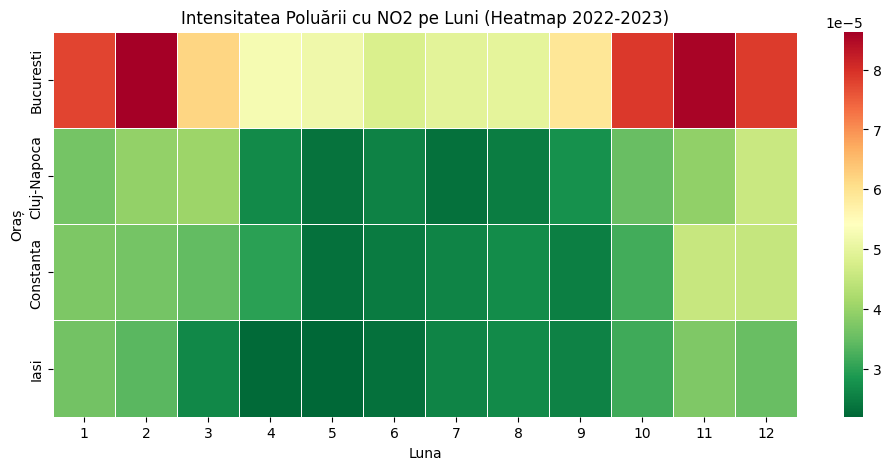

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pregătim datele sub formă de matrice (rânduri = orașe, coloane = luni)
date_matrice = df.pivot(index='Oras', columns='Luna', values='NO2')

# Generăm Heatmap-ul
plt.figure(figsize=(12, 5))
# Folosim o paletă de culori de la verde (poluare mică) la roșu închis (poluare mare)
sns.heatmap(date_matrice, cmap='RdYlGn_r', annot=False, linewidths=.5)

plt.title('Intensitatea Poluării cu NO2 pe Luni (Heatmap 2022-2023)')
plt.xlabel('Luna')
plt.ylabel('Oraș')
plt.show()

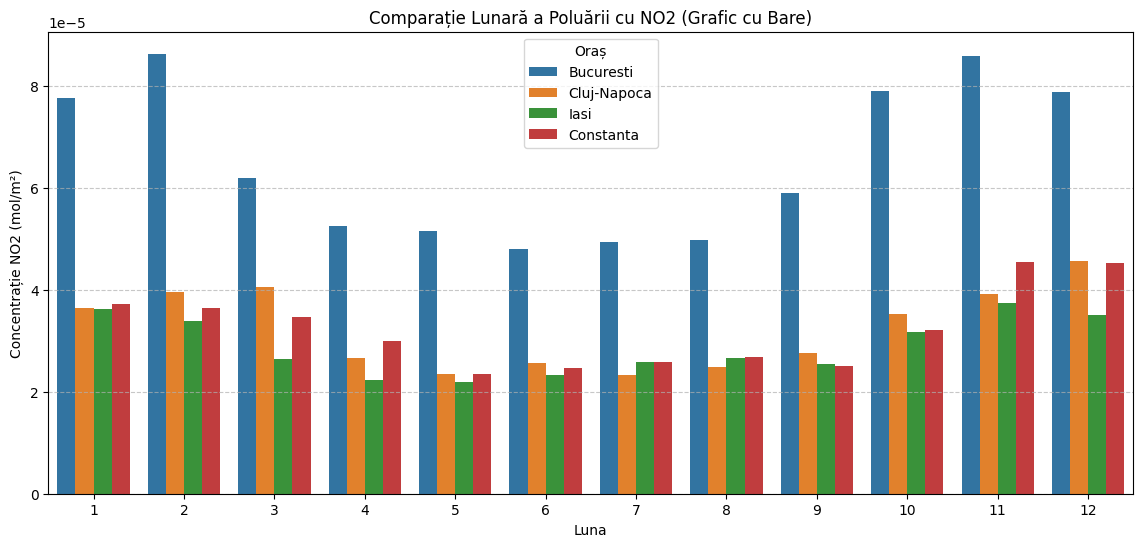

In [18]:
plt.figure(figsize=(14, 6))

# Generăm graficul cu bare folosind Seaborn
sns.barplot(data=df, x='Luna', y='NO2', hue='Oras', palette='tab10')

plt.title('Comparație Lunară a Poluării cu NO2 (Grafic cu Bare)')
plt.xlabel('Luna')
plt.ylabel('Concentrație NO2 (mol/m²)')
plt.legend(title='Oraș')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()